# Course Project - AIGC DETECTION Model testing

This notebook is used to initialize data and train the optimal model. Please modify the path of model.pth and test image to the correct one before use.

In [1]:
"""
Model evaluation script, used for analyzing model performance and checking overfitting
"""
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns
import pandas as pd
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from data_loader1 import create_data_loaders
from train_evaluate import create_model

In [2]:
##Path configuration
model_path = 'best_model.pth'  
train_root=r"C:\Users\13426\datasetai\train"
test_root=r"C:\Users\13426\datasetai\test"

In [3]:
def evaluate_model(model_path, train_root, test_root):
    """
    Comprehensively evaluate the performance of the model
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"The equipment being used: {device}")
    
    # 1. Load model
    if not os.path.exists(model_path):
        print(f"Error: Model file {model_path} doesn't exist!")
        return None
    
    print(f"Loading model: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    
    # 2. Create a data loader
    print("\nCreate a data loader...")
    try:
        # Use val_split=0.2 to obtain the validation set
        train_loader, val_loader, test_loader, class_names = create_data_loaders(
            train_root=train_root,
            test_root=test_root,
            batch_size=32,
            num_workers=4,
            val_split=0.2,  # Obtain the validation set
            use_preprocessed=True,
            seed=42  # Ensure repeatability
        )
        print(f"Category name: {class_names}")
        print(f"Training set batch: {len(train_loader)}")
        print(f"Validation set batch: {len(val_loader)}")
        print(f"Test set batch: {len(test_loader)}")
    except Exception as e:
        print(f"Failed to create the data loader: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # 3. Create and load the model
    print("\nInitialize the model...")
    try:
        model = create_model(num_classes=len(class_names), device=device, dropout_rate=0.0)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        print("The model has been loaded successfully!")
    except Exception as e:
        print(f"Model loading failed: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # 4. Check the training history
    print(f"\nModel checkpoint information:")
    for key in checkpoint.keys():
        if key not in ['model_state_dict', 'optimizer_state_dict', 'class_names']:
            print(f"  {key}: {checkpoint[key] if not isinstance(checkpoint[key], torch.Tensor) else checkpoint[key].item()}")
            
    '''
    To speed up the testing process, the evaluation test set and validation set are omitted. If necessary, comments can be removed
    # 5. Evaluate on the training set
    print("\n" + "="*50)
    print("Evaluate on the training set...")
    train_preds, train_labels, train_probs = get_predictions(model, train_loader, device)
    train_accuracy = np.mean(train_preds == train_labels) * 100
    print(f"Accuracy of the training set: {train_accuracy:.2f}% (Sample size: {len(train_labels)})")
    
    # 6. Evaluate on the validation set
    print("\n" + "="*50)
    print("Evaluate on the validation set...")
    val_preds, val_labels, val_probs = get_predictions(model, val_loader, device)
    val_accuracy = np.mean(val_preds == val_labels) * 100
    print(f"Verification set accuracy: {val_accuracy:.2f}% (Sample size: {len(val_labels)})")
    
    # 7. Print the detailed classification report
    print("\nTraining set classification report:")
    print(classification_report(train_labels, train_preds, 
                              target_names=class_names, digits=4))
    
    print("\nVerification set classification report:")
    print(classification_report(val_labels, val_preds, 
                              target_names=class_names, digits=4))
    
    # 8. Generate all visual charts
    print("\n" + "="*50)
    print("Generate all visual charts...")
    
    # 8.1 Draw the confusion matrix
    try:
        print("Generate confusion matrix...")
        plot_confusion_matrix(val_labels, val_preds, class_names, 
                            title='Validation set confusion matrix')
    except Exception as e:
        print(f"Failed to generate the confusion matrix: {e}")
        import traceback
        traceback.print_exc()
    
    # 8.2 Draw the ROC curve (only binary classification)
    try:
        print("Generate the ROC curve...")
        if len(class_names) == 2:
            plot_roc_curve(val_labels, val_probs[:, 1], class_names)
        else:
            print(f"ROC curve is only applicable to binary classification tasks，Currently here is {len(class_names)} classification")
    except Exception as e:
        print(f"The generation of the ROC curve failed: {e}")
        import traceback
        traceback.print_exc()
    
    # 8.3 Draw the precision-recall curve (only binary classification)
    try:
        print("Generate the precision-recall curve...")
        if len(class_names) == 2:
            plot_precision_recall_curve(val_labels, val_probs[:, 1], class_names)
        else:
            print(f"The PR curve is only applicable to binary classification tasks，currently here is{len(class_names)} classification")
    except Exception as e:
        print(f"Failed to generate the PR curve: {e}")
        import traceback
        traceback.print_exc()
    
    # 8.4 Draw a confidence distribution map
    try:
        print("Generate a confidence distribution map...")
        plot_confidence_distribution(train_probs, val_probs, class_names)
    except Exception as e:
        print(f"Failed to generate the confidence distribution map: {e}")
        import traceback
        traceback.print_exc()
    
    # 9. Overfitting analysis
    print("\n" + "="*50)
    print("Overfitting analysis:")
    print(f"Training accuracy: {train_accuracy:.2f}%")
    print(f"Verifing accuracy: {val_accuracy:.2f}%")
    accuracy_gap = abs(train_accuracy - val_accuracy)
    print(f"Accuracy gap: {accuracy_gap:.2f}%")
    
    if accuracy_gap > 10:
        print("⚠️  Warning: There may be severe overfitting!")
    elif accuracy_gap > 5:
        print("⚠️  Warning: There may be overfitting!")
    else:
        print("✅ The model has good generalization ability")
    '''
        
    # 10. Make predictions on the test set（No label）
    print("\n" + "="*50)
    print("Make predictions on the test set...")
    try:
        # The test set has no labels and is processed using dedicated functions
        test_predictions = predict_test_set_only(model, test_loader, device)
        
        # Save the prediction results of the test set
        save_test_predictions_only(test_predictions, class_names)
        
    except Exception as e:
        print(f"Test set prediction failed: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "="*50)
    print("The assessment is complete!")
    print("The generated file:")
    for file in ['confusion_matrix.png', 'roc_curve.png', 
                 'precision_recall_curve.png', 'confidence_distribution.png',
                 'test_predictions.csv']:
        if os.path.exists(file):
            print(f"  ✓ {file}")
        else:
            print(f"  ✗ {file} (not generated)")
    
    return model

In [4]:
def get_predictions(model, data_loader, device):
    """
    Obtain the model prediction results (applicable to labeled data)
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for batch in data_loader:
            images, labels = batch 
            
            if isinstance(labels, list):
                labels = torch.tensor(labels)
            
            images = images.to(device)
            outputs = model(images)
            
            probabilities = torch.softmax(outputs, dim=1)
            _, predictions = torch.max(outputs, 1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels), np.array(all_probabilities)

In [5]:
def predict_test_set_only(model, test_loader, device):
    """
    Only make predictions for the test set (without labels)
    """
    model.eval()
    all_predictions = []
    all_filenames = []
    all_probabilities = []
    
    with torch.no_grad():
        for batch in test_loader:
            # Test set return (images, filenames)
            images, filenames = batch
            
            images = images.to(device)
            outputs = model(images)
            
            # Obtain probabilities and predictions
            probabilities = torch.softmax(outputs, dim=1)
            _, predictions = torch.max(outputs, 1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_filenames.extend(filenames)
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return {
        'filenames': all_filenames,
        'predictions': np.array(all_predictions),
        'probabilities': np.array(all_probabilities)
    }

In [6]:
def save_test_predictions_only(test_predictions, class_names):
    """
    Save the prediction results of the test set to CSV
    """

    cleaned_filenames = []
    for filename in test_predictions['filenames']:
        # Remove.jpg or other extensions
        if '.' in filename:
            cleaned_name = filename.rsplit('.', 1)[0]
        else:
            cleaned_name = filename
        cleaned_filenames.append(cleaned_name)
    '''
    results_df = pd.DataFrame({
        'ID': test_predictions['filename'],
        'label': test_predictions['prediction']
    })
    '''
    results_df = pd.DataFrame({
        'ID': cleaned_filenames,
        'label': test_predictions['predictions']
    })

    csv_path = 'test_predictions.csv'
    results_df.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"The prediction results of the test set have been saved to: {csv_path}")

    return results_df


In [7]:
def plot_confusion_matrix(y_true, y_pred, class_names, title='混淆矩阵'):
    """
    Draw the confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('"True label"')
    plt.xlabel('Predictive label')
    plt.tight_layout()
    
    save_path = 'confusion_matrix.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"The confusion matrix has been saved to: {save_path}")

In [8]:
def plot_roc_curve(y_true, y_scores, class_names):
    """
    Draw the ROC curve (only binary classification)
    """
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲线 (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_path = 'roc_curve.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"The ROC curve has been saved to: {save_path}, AUC: {roc_auc:.3f}")

In [9]:
def plot_precision_recall_curve(y_true, y_scores, class_names):
    """
    Draw the precision-recall curve (only binary classification)
    """
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label='PR curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision - recall curve')
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_path = 'precision_recall_curve.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"The precision-recall curve has been saved to: {save_path}")

In [10]:
def plot_confidence_distribution(train_probs, val_probs, class_names):
    """
    Draw the distribution of prediction confidence levels
    """
    plt.figure(figsize=(12, 5))
    
    # Draw the distribution of prediction confidence levels
    plt.subplot(1, 2, 1)
    train_confidences = train_probs.max(axis=1)
    plt.hist(train_confidences, bins=30, alpha=0.7, color='blue', edgecolor='black', label='训练集')
    plt.xlabel('Prediction confidence level')
    plt.ylabel('Sample size')
    plt.title('The confidence distribution of the training set prediction')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add statistical information
    plt.text(0.05, 0.95, f'Mean: {train_confidences.mean():.3f}\nStandard deviation: {train_confidences.std():.3f}',
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # The confidence distribution of the validation set
    plt.subplot(1, 2, 2)
    val_confidences = val_probs.max(axis=1)
    plt.hist(val_confidences, bins=30, alpha=0.7, color='orange', edgecolor='black', label='验证集')
    plt.xlabel('Prediction confidence level')
    plt.ylabel('Sample size')
    plt.title('The confidence distribution of the validation set prediction')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add statistical information
    plt.text(0.05, 0.95, f'Mean: {val_confidences.mean():.3f}\nStandard deviation: {val_confidences.std():.3f}',
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    save_path = 'confidence_distribution.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"The confidence distribution map has been saved to:{save_path}")


The equipment being used: cuda
Loading model: best_model.pth

Create a data loader...
训练集类别: ['0_real', '1_fake']
总训练样本数: 50000
类别分布: {'0_real': 25000, '1_fake': 25000}
训练集样本数: 40000
验证集样本数: 10000
在测试集中找到 2500 张图片。
测试集样本数: 2500
Category name: ['0_real', '1_fake']
Training set batch: 1250
Validation set batch: 313
Test set batch: 79

Initialize the model...
总参数: 24,033,090, 可训练参数: 18,518,786
The model has been loaded successfully!

Model checkpoint information:
  epoch: 5
  train_loss: 0.00660515604019165
  train_acc: 99.805
  val_loss: 0.00803544265679506
  val_acc: 99.79

Evaluate on the training set...
Accuracy of the training set: 99.95% (Sample size: 40000)

Evaluate on the validation set...
Verification set accuracy: 99.83% (Sample size: 10000)

Training set classification report:
              precision    recall  f1-score   support

      0_real     0.9997    0.9993    0.9995     19993
      1_fake     0.9994    0.9997    0.9995     20007

    accuracy                         0.

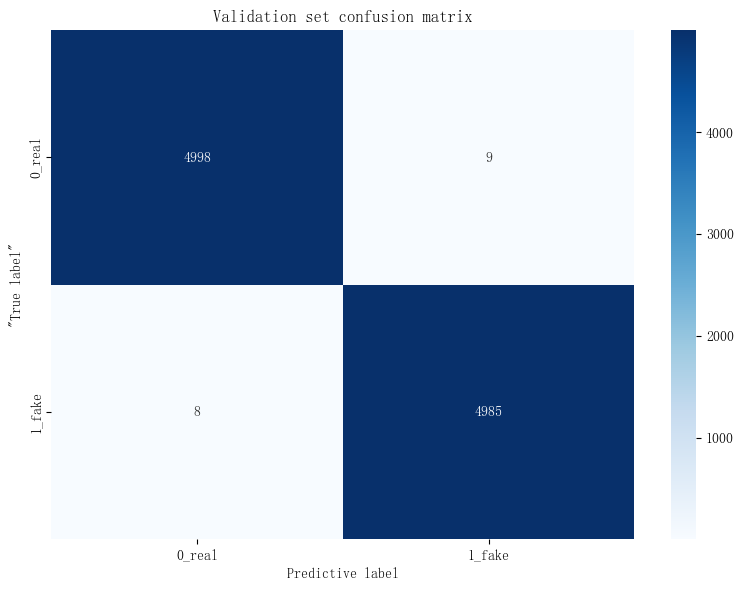

The confusion matrix has been saved to: confusion_matrix.png
Generate the ROC curve...


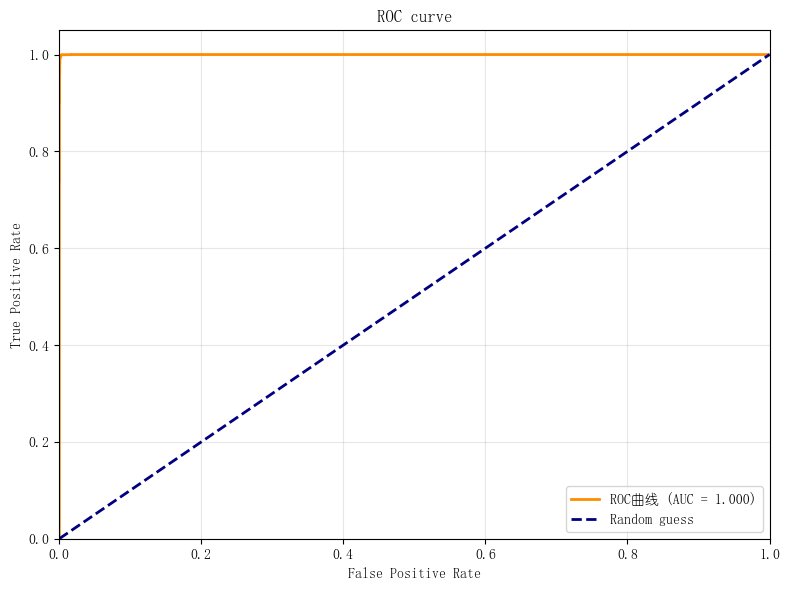

The ROC curve has been saved to: roc_curve.png, AUC: 1.000
Generate the precision-recall curve...


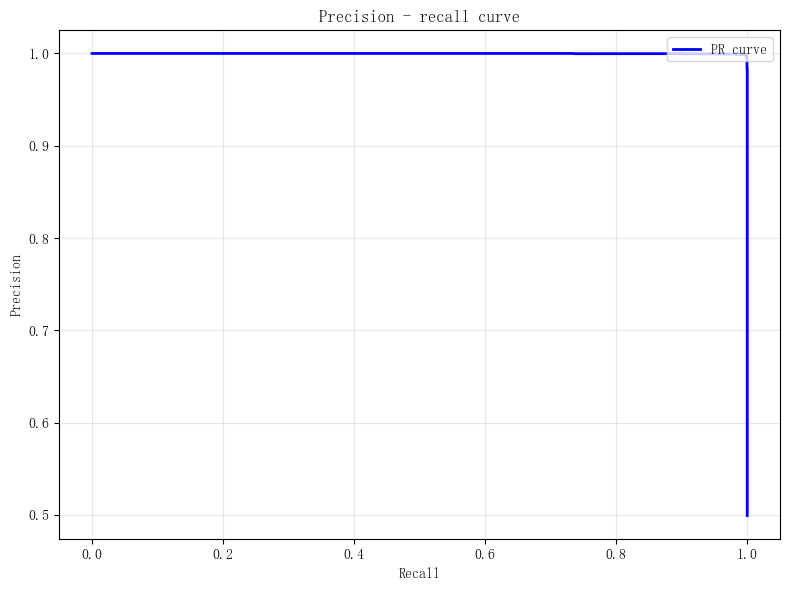

The precision-recall curve has been saved to: precision_recall_curve.png
Generate a confidence distribution map...


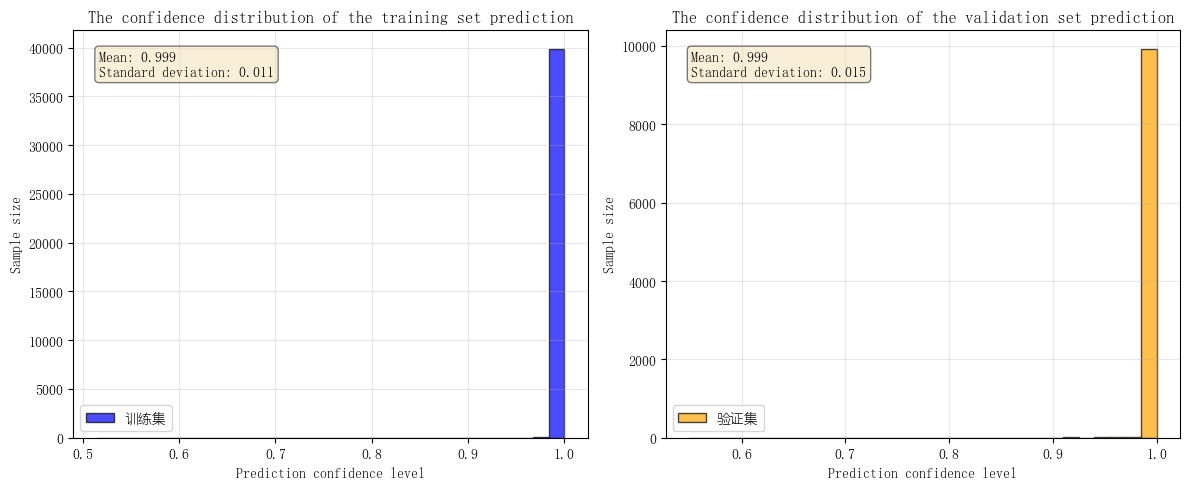

The confidence distribution map has been saved to:confidence_distribution.png

Overfitting analysis:
Training accuracy: 99.95%
Verifing accuracy: 99.83%
Accuracy gap: 0.12%
✅ The model has good generalization ability

Make predictions on the test set...
The prediction results of the test set have been saved to: test_predictions.csv

The assessment is complete!
The generated file:
  ✓ confusion_matrix.png
  ✓ roc_curve.png
  ✓ precision_recall_curve.png
  ✓ confidence_distribution.png
  ✓ test_predictions.csv


In [11]:
if __name__ == '__main__':
    # Add command-line parameter support
    import argparse
    
    parser = argparse.ArgumentParser(description='Evaluate AI image detection models')
    parser.add_argument('--model', type=str, default=model_path , help='Model file path')
    parser.add_argument('--train_root', type=str, default=train_root, help='Root directory of the training set')
    parser.add_argument('--test_root', type=str, default=test_root, help='Root directory of the test set')
    
    args = parser.parse_args(args=[])
    
    evaluate_model(
        model_path=args.model,
        train_root=args.train_root,
        test_root=args.test_root
    )